# NucleotideTransformer Scoring — LTEE SNPs (masked-marginal LLR)

Score every SNP (coding + non-coding) with InstaDeep's genome language model using a **proper masked-marginal log-likelihood ratio** at the mutation position:

$$
\mathrm{NT\,LLR}\;=\;\log P(\text{ALT} \mid \text{masked context}) \;-\; \log P(\text{REF} \mid \text{masked context})
$$

For each SNV, the 6-mer token(s) overlapping the mutation site are replaced with `[MASK]`, and the model's vocabulary distribution at the masked position is aggregated into per-base probabilities by summing 6-mer tokens whose offset-`j` character equals each base. This yields a base-resolution LLR that depends only on the mutation site, **not** a whole-sequence pseudo-likelihood (which dilutes the per-position signal across all sequence-identical tokens).


**Requirements:** `pip install transformers torch biopython` · GPU strongly recommended.

**Note on legacy scores:** an earlier version of this notebook used a whole-sequence pseudo-likelihood difference, which is *not* a per-position LLR. If you have results from that version, regenerate them with `scoring='masked_marginal'` (default) before drawing per-position conclusions.

In [1]:
"""Setup: project root + data directory."""
from pathlib import Path
import sys

_here = Path('.').resolve()
for _p in [_here, *_here.parents]:
    if (_p / 'data').is_dir():
        PROJECT_ROOT = _p
        break
else:
    PROJECT_ROOT = _here

DATA_DIR = PROJECT_ROOT / 'data'
sys.path.insert(0, str(PROJECT_ROOT))   # utility.py lives at PROJECT_ROOT/utility.py

import pandas as pd
import numpy as np
from scipy import stats
print(f'Project root : {PROJECT_ROOT}')
print(f'Data dir     : {DATA_DIR}')

Project root : /home/abhishekh/iScience code-20260404T073214Z-1-001/iScience code/code
Data dir     : /home/abhishekh/iScience code-20260404T073214Z-1-001/iScience code/code/data


## Configuration

In [2]:
# ---- User settings ----
FASTA_PATH    = DATA_DIR / 'GCF_000017985.1_ASM1798v1_genomic.fna'
MUTATIONS_CSV = DATA_DIR / 'kgain_all_population_wt.csv'
OUT_CSV       = 'nt_scores.csv'
FLANK_SIZE    = 256          # bases each side → 513-bp context window (matches DNABERT standard)
BATCH_SIZE    = 8192

SCORING_MODE  = 'masked_marginal'

MODEL_NAME     = 'InstaDeepAI/nucleotide-transformer-v2-500m-multi-species'
MODEL_REVISION = '06615c1660c892fc199840c18123f8385b3542a8'  # pinned commit → matches nt_scores.csv
HF_TOKEN       = None

# ── Reproducibility ──────────────────────────────────────────────────────────
import torch, transformers, numpy as np_version_check

torch.backends.cudnn.deterministic = True   # deterministic cuDNN kernels
torch.backends.cudnn.benchmark     = False  # disable fastest-kernel auto-selection
torch.use_deterministic_algorithms(True, warn_only=True)  # catch non-deterministic ops

print(f"torch        : {torch.__version__}")
print(f"transformers : {transformers.__version__}")
print(f"Model        : {MODEL_NAME}  @  {MODEL_REVISION}")
print(f"cuDNN deterministic : {torch.backends.cudnn.deterministic}")

torch        : 2.11.0+cu130
transformers : 4.33.3
Model        : InstaDeepAI/nucleotide-transformer-v2-500m-multi-species  @  06615c1660c892fc199840c18123f8385b3542a8
cuDNN deterministic : True


## Load Mutations

In [3]:
mutations_df = pd.read_csv(MUTATIONS_CSV)
mutations_df.columns = mutations_df.columns.str.strip()
print(f'Loaded {len(mutations_df)} mutations, columns: {list(mutations_df.columns[:8])}')
mutations_df.head(3)

Loaded 36922 mutations, columns: ['#CHROM', 'POS', 'REF', 'ALT', 'ref_flank_seq', 'mutated_flank_seq', 'wild_type_kGain', 'population_label']


,#CHROM,POS,REF,ALT,ref_flank_seq,mutated_flank_seq,wild_type_kGain,population_label,unique_mutation_key
0,chrI,851,C,T,GTCCACCCGCCGTATTGCG,GTCCACCCGTCGTATTGCG,-8.764470,m3,chrI_C_851_T_m3
1,chrI,1521,C,T,ACGGAACGGCTGGCCATTA,ACGGAACGGTTGGCCATTA,-11.203187,m3,chrI_C_1521_T_m3
2,chrI,1612,A,G,CCAATATCAACATTGTCGC,CCAATATCAGCATTGTCGC,-2.844573,m3,chrI_A_1612_G_m3


## Run NucleotideTransformer Pipeline

In [4]:
import importlib.util, traceback, sys
from pathlib import Path

# Evict any stale cached version from the kernel's sys.modules
for _k in list(sys.modules):
    if 'nucleotide_transformer_scoring' in _k:
        del sys.modules[_k]

# Load fresh from absolute path (sibling .py file)
_nt_path = Path('nucleotide_transformer_scoring.py').resolve()
if not _nt_path.exists():
    # Fallback: search a couple of likely locations
    for _candidate in [
        Path.cwd() / 'nucleotide_transformer_scoring.py',
        PROJECT_ROOT / 'code' / 'thermodynamics' / 'nucleotide_transformer_scoring.py',
    ]:
        if _candidate.exists():
            _nt_path = _candidate
            break

_spec = importlib.util.spec_from_file_location('nucleotide_transformer_scoring', str(_nt_path))
_mod  = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
print('Module loaded from:', _nt_path)
print('Has run_nt_pipeline:', hasattr(_mod, 'run_nt_pipeline'))

try:
    nt_df = _mod.run_nt_pipeline(
        fasta_path   = FASTA_PATH,
        mutations_df = mutations_df,
        out_csv      = OUT_CSV,
        flank_size   = FLANK_SIZE,
        model_name   = MODEL_NAME,
        revision     = MODEL_REVISION,
        hf_token     = HF_TOKEN,
        batch_size   = BATCH_SIZE,
        pos_col      = 'POS',
        ref_col      = 'REF',
        alt_col      = 'ALT',
        scoring      = SCORING_MODE,
    )
    print(f'Shape: {nt_df.shape}')
    print(f'Scoring method: {nt_df["nt_scoring_method"].iloc[0]}')
    print(f'Median NT LLR: {nt_df["nt_llr"].median():.4f}')
    print(f'N scored      : {nt_df["nt_llr"].notna().sum()}')
    nt_df.head()
except Exception as e:
    print(f'[Pipeline error] {e}')
    traceback.print_exc()
    nt_df = None

Module loaded from: /home/abhishekh/iScience code-20260404T073214Z-1-001/iScience code/code/figure/Supplementary/fig2/nucleotide_transformer_scoring.py
Has run_nt_pipeline: True
Loaded FASTA: 4,629,812 bp
Loading InstaDeepAI/nucleotide-transformer-v2-500m-multi-species on cuda ...
[Info] Using pinned revision: 06615c1660c892fc199840c18123f8385b3542a8
[Stage 1 failed] ValueError: Loading InstaDeepAI/nucleotide-transformer-v2-500m-multi-species requires you to execute the configuration file in that repo on your local machine. Make sure you have read the code there to avoid malicious use, then set the option `trust_remote_code=True` to remove this error.


/home/abhishekh/anaconda3/envs/pseudotime/lib/python3.11/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/abhishekh/anaconda3/envs/pseudotime/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/home/abhishekh/anaconda3/envs/pseudotime/lib/python3.11/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


[Info] Loaded with trust_remote_code=True.


NT scoring (masked_marginal): 100%|██████████| 5/5 [13:51<00:00, 166.32s/it]


Wrote: nt_scores.csv
Shape: (36922, 11)
Scoring method: masked_marginal
Median NT LLR: -0.1259
N scored      : 36922


## Summary Statistics

## Sanity check — masked-marginal LLR validation

If the scoring is well-formed, the LLR distribution should be roughly centred near zero (most random mutations are mildly disfavored under a masked LM trained across thousands of genomes), with broad tails. The fraction of positive vs negative LLRs reports the empirical balance of mutations the model considers more vs less likely than the reference.

If you see all-zero or all-NaN scores, check:
1. The tokenizer's vocabulary contains DNA k-mer tokens (the indicator builder warns if not).
2. The mutation positions in `mutations_df` are 1-based and match the FASTA reference.
3. `flank_size` is large enough that the mutation isn't right at the edge of the window.

In [5]:
if nt_df is not None:
    s = nt_df['nt_llr']
    method = nt_df['nt_scoring_method'].iloc[0] if 'nt_scoring_method' in nt_df.columns else 'unknown'
    print(f'Scoring method : {method}')
    print(f'N scored       : {s.notna().sum()}')
    print(f'Median LLR     : {s.median():.4f}')
    print(f'Mean LLR       : {s.mean():.4f}')
    print(f'Std LLR        : {s.std():.4f}')
    print(f'Frac LLR < 0   : {(s < 0).mean():.3f}  (alt less probable than ref)')
    print(f'Frac LLR > 0   : {(s > 0).mean():.3f}  (alt more probable than ref)')
else:
    print('No scores available.')

Scoring method : masked_marginal
N scored       : 36922
Median LLR     : -0.1259
Mean LLR       : -0.1418
Std LLR        : 1.2227
Frac LLR < 0   : 0.553  (alt less probable than ref)
Frac LLR > 0   : 0.447  (alt more probable than ref)


## Correlation with ΔΔG

Merge NT scores with kGain/ΔΔG data if available.

In [6]:
# ── 1. Unique-mutation-wise correlation ──────────────────────────────────────
if nt_df is not None:
    # Deduplicate to one row per unique mutation
    mut_df = nt_df.drop_duplicates(subset='unique_mutation_key').dropna(subset=['nt_llr'])

    # Correlation: NT LLR vs wild-type kGain
    if 'wild_type_kGain' in mut_df.columns:
        valid_k = mut_df[['nt_llr', 'wild_type_kGain']].dropna()
        rho_k, p_k = stats.spearmanr(valid_k['nt_llr'], valid_k['wild_type_kGain'])
        r_k,  pr_k = stats.pearsonr( valid_k['nt_llr'], valid_k['wild_type_kGain'])
        print(f"Unique-mutation correlation  (N={len(valid_k)})")
        print(f"  Spearman(NT_LLR, kGain): rho={rho_k:.4f}, p={p_k:.2e}")
        print(f"  Pearson (NT_LLR, kGain): r  ={r_k:.4f},  p={pr_k:.2e}")

    # Try to load ddG from sift4g_scores.csv (has POS, REF, ALT, sift_score)
    ddg_path = DATA_DIR.parent.parent / 'thermodynamics' / 'sift4g_scores.csv'
    if not ddg_path.exists():
        ddg_path = Path(__file__).parent / 'sift4g_scores.csv' \
            if '__file__' in dir() else \
            Path('/home/abhishekh/iScience code-20260404T073214Z-1-001/iScience code/code/thermodynamics/sift4g_scores.csv')
    if ddg_path.exists():
        ddg_df = pd.read_csv(ddg_path)
        ddg_df.columns = ddg_df.columns.str.strip()
        if 'ddG' in ddg_df.columns:
            merged_ddg = mut_df.merge(
                ddg_df[['POS','REF','ALT','ddG']].drop_duplicates(),
                on=['POS','REF','ALT'], how='inner'
            ).dropna(subset=['nt_llr','ddG'])
            if len(merged_ddg) >= 3:
                rho_d, p_d = stats.spearmanr(merged_ddg['nt_llr'], merged_ddg['ddG'])
                r_d,  pr_d = stats.pearsonr( merged_ddg['nt_llr'], merged_ddg['ddG'])
                print(f"\nSpearman(NT_LLR, ddG): rho={rho_d:.4f}, p={p_d:.2e}  (N={len(merged_ddg)})")
                print(f"Pearson (NT_LLR, ddG): r  ={r_d:.4f},  p={pr_d:.2e}")
        else:
            print("ddG column not in sift4g_scores.csv")
    else:
        print("sift4g_scores.csv not found — skipping ddG correlation")

Unique-mutation correlation  (N=36922)
  Spearman(NT_LLR, kGain): rho=0.0714, p=6.19e-43
  Pearson (NT_LLR, kGain): r  =0.0736,  p=1.77e-45
ddG column not in sift4g_scores.csv


## Generation-wise NT LLR trajectory and correlation

In [7]:
# ── 2. Build generation-wise long format ────────────────────────────────────
if nt_df is not None:
    annot_df = pd.read_csv(DATA_DIR / 'concat_pop_annotation.csv')
    annot_df.columns = annot_df.columns.str.strip()
    # Strip leading/trailing spaces from string value columns
    for _c in ['Ref_allele', 'Alt_allele', 'Allele', 'Gene']:
        if _c in annot_df.columns:
            annot_df[_c] = annot_df[_c].astype(str).str.strip()

    # Parse Allele ("T->G") → Ref_allele / Alt_allele if needed
    if 'Allele' in annot_df.columns and 'Ref_allele' not in annot_df.columns:
        _split = annot_df['Allele'].str.split('->', expand=True)
        annot_df['Ref_allele'] = _split[0].str.strip().str.upper()
        annot_df['Alt_allele'] = _split[1].str.strip().str.upper()

    # Identify AC/DP generation columns
    # Keep only real LTEE generation timepoints (≤ 60000)
    # Columns like AC:1000500 are population×generation encoded IDs — exclude them
    ac_cols = [c for c in annot_df.columns
               if c.startswith('AC:') and ':' in c and int(c.split(':')[1]) <= 60000]
    dp_cols = [c for c in annot_df.columns
               if c.startswith('DP:') and ':' in c and int(c.split(':')[1]) <= 60000]
    generations = sorted({int(c.split(':')[1]) for c in ac_cols})
    print(f'Valid generations: {min(generations)} – {max(generations)}  ({len(generations)} timepoints)')

    # Melt to long format: one row per (mutation × generation)
    rows = []
    for gen in generations:
        ac_col = f'AC:{gen}'
        dp_col = f'DP:{gen}'
        if ac_col not in annot_df.columns:
            continue
        tmp = annot_df[['Position', 'Ref_allele', 'Alt_allele', ac_col, dp_col]].copy()
        tmp = tmp.rename(columns={ac_col: 'AC', dp_col: 'DP'})
        tmp['generation'] = gen
        rows.append(tmp)

    long_df = pd.concat(rows, ignore_index=True)
    long_df['Position'] = pd.to_numeric(long_df['Position'], errors='coerce')

    # Merge with NT scores
    nt_unique = nt_df.drop_duplicates(subset=['POS','REF','ALT'])[
        ['POS','REF','ALT','unique_mutation_key','nt_llr','wild_type_kGain']
    ].copy()
    nt_unique['POS'] = pd.to_numeric(nt_unique['POS'], errors='coerce')

    gen_long = long_df.merge(
        nt_unique.rename(columns={'POS':'Position','REF':'Ref_allele','ALT':'Alt_allele'}),
        on=['Position','Ref_allele','Alt_allele'], how='inner'
    )
    gen_long = gen_long[gen_long['AC'] > 0].dropna(subset=['nt_llr'])
    print(f"Generation-wise long format: {len(gen_long):,} rows  "
          f"({gen_long['generation'].nunique()} generations, "
          f"{gen_long['unique_mutation_key'].nunique()} unique mutations)")
    gen_long.head(3)

Valid generations: 0 – 60000  (117 timepoints)
Generation-wise long format: 1,136,782 rows  (117 generations, 34391 unique mutations)


In [8]:
nt_df

,#CHROM,POS,REF,ALT,ref_flank_seq,mutated_flank_seq,wild_type_kGain,population_label,unique_mutation_key,nt_llr,nt_scoring_method
0,chrI,851,C,T,GTCCACCCGCCGTATTGCG,GTCCACCCGTCGTATTGCG,-8.764470,m3,chrI_C_851_T_m3,-2.157937,masked_marginal
1,chrI,1521,C,T,ACGGAACGGCTGGCCATTA,ACGGAACGGTTGGCCATTA,-11.203187,m3,chrI_C_1521_T_m3,0.212223,masked_marginal
2,chrI,1612,A,G,CCAATATCAACATTGTCGC,CCAATATCAGCATTGTCGC,-2.844573,m3,chrI_A_1612_G_m3,-0.134381,masked_marginal
3,chrI,3988,G,A,CCGGCTCCGGTCGCCAATG,CCGGCTCCGATCGCCAATG,-9.244451,m3,chrI_G_3988_A_m3,-0.295358,masked_marginal
4,chrI,6394,A,G,GCAGCGTATAGCGCGTGGT,GCAGCGTATGGCGCGTGGT,7.647503,m3,chrI_A_6394_G_m3,1.050344,masked_marginal
...,...,...,...,...,...,...,...,...,...,...,...
36917,chrI,4627281,C,T,TTTTTGAAACGCTCACCGC,TTTTTGAAATGCTCACCGC,-4.515558,m2,chrI_C_4627281_T_m2,0.217775,masked_marginal
36918,chrI,4628190,G,A,CGATTTCGAGGCCGAGAAT,CGATTTCGAAGCCGAGAAT,-1.791759,m2,chrI_G_4628190_A_m2,0.292622,masked_marginal
36919,chrI,4629386,A,G,AGAACTGGTACCGCTGTTA,AGAACTGGTGCCGCTGTTA,7.409069,m2,chrI_A_4629386_G_m2,-0.122626,masked_marginal
36920,chrI,4629441,C,T,GTGTTTGGTCGCGAAGATT,GTGTTTGGTTGCGAAGATT,-8.417367,m2,chrI_C_4629441_T_m2,0.486383,masked_marginal


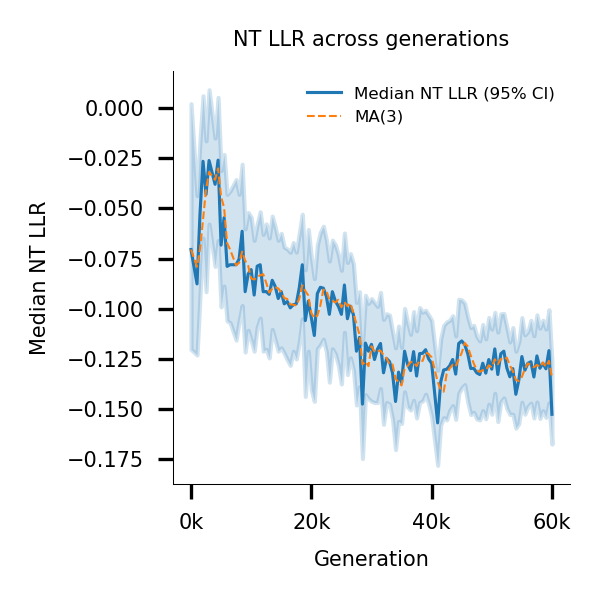

Saved nt_llr_generation_wise.pdf


In [9]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt
import seaborn as sns

if nt_df is not None and 'gen_long' in dir():
    # ── Generation-wise median stats ──────────────────────────────────────────
    gen_stats = (
        gen_long.groupby('generation')
        .agg(
            median_nt_llr=('nt_llr',             'median'),
            median_kGain =('wild_type_kGain',     'median'),
            n_mutations  =('unique_mutation_key', 'nunique'),
        )
        .reset_index()
    )
    gen_stats = gen_stats.sort_values('generation')
    gen_stats['ma3_nt_llr'] = gen_stats['median_nt_llr'].rolling(window=3, min_periods=1).mean()

    # ── Plot ─────────────────────────────────────────────────────────────────
    fs = 5
    fig, ax = plt.subplots(1, 1, figsize=(2.1, 2.1), dpi=300)

    # Median NT LLR over generations with bootstrapped 95% CI (matches fig3)
    sns.lineplot(
        data=gen_long,
        x='generation',
        y='nt_llr',
        estimator=np.median,
        errorbar=('ci', 95),
        # n_boot=2000,
        lw=0.75,
        label='Median NT LLR (95% CI)',
        ax=ax,
    )
    # MA(3) via second sns.lineplot on pre-aggregated median series (matches fig3)
    sns.lineplot(
        data=gen_stats,
        x='generation',
        y='ma3_nt_llr',
        lw=0.5,
        linestyle='--',
        label='MA(3)',
        ax=ax,
    )
    ax.set_xlabel('Generation', fontsize=fs)
    ax.set_ylabel('Median NT LLR', fontsize=fs)
    ax.set_title('NT LLR across generations', fontsize=fs)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x/1000)}k'))
    ax.spines[["top", "right"]].set_visible(False)
    for sp in ax.spines.values(): sp.set_linewidth(0.25)
    ax.tick_params(labelsize=fs)
    ax.legend(fontsize=fs - 1, frameon=False)

    fig.tight_layout()
    fig.savefig('nt_llr_generation_wise.pdf', format='pdf', bbox_inches='tight')
    plt.show()
    print("Saved nt_llr_generation_wise.pdf")
    gen_stats.head()

In [12]:
import utility

if 'gen_long' in dir():
    p_nt, tau_nt = utility.dba_stat(
        data=gen_long[["generation", "nt_llr"]],
        group_by_col="generation",
        target_col_name="nt_llr",
        num_permutations=10000,
        random_state=42
    )
    print(f"Kendall τ = {tau_nt:.4f},  permutation p = {p_nt:.4e}")
else:
    print("gen_long not available — run generation-wise cell first.")

Kendall τ = -0.6671,  permutation p = 1.0000e+00
